---
title: Wildfire Burn Severity Assessment Using Sentinel-2 L2A Data and dNBR
subtitle: A hands-on tutorial using EOPF STAC Zarr datasets, Dask and  Xarray to map and quantify burnt areas for the Peneda-Gerês wildfire event (Portugal, July 2025).
authors:
  - name: Suriyah Dhinakaran
    orcid: 0009-0007-0355-7372
    github: suriyahgit
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Anne Fouilloux
    orcid: 0000-0002-1784-2920
    github: annefou
    affiliations:
      - id: Simula Research Laboratory
        institution: Simula Research Laboratory
        ror: 00vn06n10
  - name: Deyan Samardzhiev
    github: sunnydean
    orcid: 0009-0003-3803-8522
    affiliations:
      - id: Lampata UK
        institution: Lampata UK
date: 2025-11-17
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing"]
tags: ["stac"]
releaseDate: 2025-11-17
datePublished: 2025-11-17
dateModified: 2025-11-17
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

# Table of Contents

1. [Introduction](#intro_FIRE)
2. [Justification for Temporal and Spatial Bounds](#spatial_FIRE)
3. [Overview](#overview_FIRE)
4. [Setup](#setup_FIRE)
5. [Create and Startup Dask Cluster](#dask_FIRE)
6. [Analysing in Detail](#analysing_FIRE)
7. [Pre-Event Data Preparation](#pre_data_FIRE)
8. [Post-Event Data Preparation](#post_data_FIRE)
9. [Calculating the NBR Index](#nbr_FIRE)
10. [Plotting and Visualization](#plotting_FIRE)
11. [Analysing Burnt Areas](#areas_FIRE)
12. [Burnt Area](#burnt_area_FIRE)
13. [Links and References](#links_FIRE)


(intro_FIRE)=
# Introduction

Wildfires are one of the most destructive natural hazards affecting ecosystems, biodiversity, and local communities. 
For Earth Observation (EO)-based wildfire impact assessment, it is essential to define appropriate temporal ranges 
before and after the event to analyse vegetation conditions, burned area characteristics, and severity using indices 
such as Normalised Burn Ratio(NBR) and delta NBR(dNBR).

In this notebook, we focus on the **Peneda-Gerês / Ponte da Barca wildfire**, located in the **north-western region 
of Portugal**, close to the **border with Spain**. This area is part of the Peneda-Gerês National Park, a region with 
dense forest cover and rich ecological value, making it a critical location for post-fire environmental monitoring. 

We analyse multi-temporal Sentinel-2 L2A imagery covering:
- **Event date** → 2025-07-26
- **± 1 month window** around the fire event
- **Extended pre- and post-event periods** to study vegetation recovery




(spatial_FIRE)=
# Justification for Temporal and Spatial Bounds

### Temporal Window Justification

For this analysis we selected a **one-month pre-fire and one-month post-fire comparison window**, rather than a 15-day range. Using a longer time window helps reduce the influence of short-term atmospheric variations, cloud cover issues, and rapid phenological changes common in the summer season.

The defined periods are:

- **Event date (Ignition date):** 2025-07-26
- **Week before event:** 2025-07-19
- **Week after event:** 2025-08-02
- **Pre-event period:** 2025-06-20 → 2025-07-19
- **Post-event period:** 2025-08-02 → 2025-09-02

### Why 1-month windows?

Using a 30-day window before and after the wildfire ensures:

- **Stable baseline vegetation conditions** for comparison — reducing noise due to daily fluctuations.
- **Greater probability of cloud-free Sentinel-2 acquisitions**, improving the reliability of pre/post composite images.
- **Better representation of ecological response**, as vegetation recovery or burn scar persistence is visible over weeks, not days.
- **Alignment with wildfire monitoring standards**, where analytical best practice recommends at least ~1 month around the fire for robust burn severity and vegetation-change evaluation.

A shorter ±15-day period may miss key signals because:

- Sentinel-2 revisit time (5 days per tile but impacted by cloud cover) can limit usable scenes,
- Vegetation stress and burn severity spectral response evolve across several weeks.

Thus, the 1-month buffer enables more accurate **dNBR burn scar** quantification.

### Spatial Extent Justification

The region of interest covers the **Peneda-Gerês / Ponte da Barca wildfire zone**, located in **north-west Portugal on the border with Spain**. This AOI fully encompasses the reported burn perimeter and surrounding vegetation for comparison. The selected spatial boundary:

- Captures the entire affected ecosystem within the Peneda-Gerês National Park,
- Includes buffer land surrounding the burn to analyze edge effects and severity gradients,
- Minimizes processing cost by avoiding unnecessary surrounding territory.

This spatial coverage is ecologically and operationally important because:

- Peneda-Gerês is Portugal’s only national park and a biodiversity hotspot,
- The region shares a transboundary forest system with Spain,
- Dense vegetation and rugged topography accelerate fire spread and intensify burn patterns.

Together, the temporal and spatial definitions provide a scientifically justified foundation for a comprehensive wildfire impact assessment using Sentinel-2 L2A imagery.

(overview_FIRE)=
## Overview
:::{hint}

### Questions
• What is the temporal and spatial scope chosen to analyze the Peneda-Gerês / Ponte da Barca wildfire event?
• How do the selected pre-event and post-event Sentinel-2 scenes differ visually across the affected area?
• How can the Normalized Burn Ratio (NBR) and its difference (dNBR) help quantify the impact of the wildfire?

### Objectives
• Load and visualize Sentinel-2 data for the defined wildfire region and selected pre- and post-event periods.
• Compute NBR and dNBR from pre-event and post-event Sentinel-2 composites.
• Compare and interpret NBR-based change to document and evaluate wildfire effects.

:::


(setup_FIRE)=
## Setup
Start importing the necessary libraries

In [1]:
from dask_gateway import Gateway

from xcube.core.store import new_data_store
from xcube_eopf.utils import reproject_bbox

(dask_FIRE)=
## Create and Startup Dask Cluster
Create Local Dask Cluster to access and process the data in parallel.

In [2]:
# Simplest way - creates everything automatically in the eopf jupyterhub dask cluster
gate = Gateway()
cluster = gate.new_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 98.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43663,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38405,Total threads: 4
Dashboard: http://127.0.0.1:38853/status,Memory: 24.56 GiB
Nanny: tcp://127.0.0.1:43589,


(analysing_FIRE)=
## Analysing in Detail
Now that we have an idea of a potential wildfire event, we can explore in a bit more detail to see what areas where affected most. 

We will use higher resolution sentinel-2-l2a data to compute the Normalised Burn Ratio (NBR) index to highlight burned areas. The NBR index uses near-infrared (NIR) and shortwave-infrared (SWIR) wavelengths. We will use xcube-eopf package to search and extract required data for cloud free days. 

To estimate the amount of burnt area we will compute the difference between the NBR from period before the fire date and the NBR from the period after. The first step is to select the week before and the week after the wildfire.

(pre_data_FIRE)=
## Pre-Event Data Preparation

In [3]:
store = new_data_store("eopf-zarr")
bbox_4326 = [-8.375, 41.700, -8.075, 41.875]
crs_utm = "EPSG:32629"
bbox_utm = reproject_bbox(bbox_4326, "EPSG:4326", crs_utm)
prefire_ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=bbox_utm,
    time_range=["2025-06-20", "2025-07-19"],
    spatial_res=10,
    crs=crs_utm,
    variables=["b08", "b12"],
    query={"eo:cloud_cover": {"lt": 20}},
)
print(prefire_ds)
prefire_ds = prefire_ds.mean(dim="time")
prefire_ds

<xarray.Dataset> Size: 553MB
Dimensions:      (time: 7, y: 1967, x: 2511)
Coordinates:
  * time         (time) datetime64[ns] 56B 2025-06-20T11:33:19.024000 ... 202...
    spatial_ref  int64 8B ...
  * x            (x) float64 20kB 5.519e+05 5.519e+05 ... 5.77e+05 5.77e+05
  * y            (y) float64 16kB 4.636e+06 4.636e+06 ... 4.617e+06 4.617e+06
Data variables:
    b08          (time, y, x) float64 277MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b12          (time, y, x) float64 277MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (4)


<xarray.Dataset> Size: 79MB
Dimensions:      (y: 1967, x: 2511)
Coordinates:
    spatial_ref  int64 8B ...
  * x            (x) float64 20kB 5.519e+05 5.519e+05 ... 5.77e+05 5.77e+05
  * y            (y) float64 16kB 4.636e+06 4.636e+06 ... 4.617e+06 4.617e+06
Data variables:
    b08          (y, x) float64 40MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12          (y, x) float64 40MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>

(post_data_FIRE)=
## Post-Event Data Preparation

In [4]:
store = new_data_store("eopf-zarr")
bbox_4326 = [-8.375, 41.700, -8.075, 41.875]
crs_utm = "EPSG:32629"
bbox_utm = reproject_bbox(bbox_4326, "EPSG:4326", crs_utm)
postfire_ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=bbox_utm,
    time_range=["2025-08-02", "2025-09-02"],
    spatial_res=10,
    crs=crs_utm,
    variables=["b08", "b12"],
    query={"eo:cloud_cover": {"lt": 20}},
)
print(postfire_ds)
postfire_ds = postfire_ds.mean(dim="time")
postfire_ds

<xarray.Dataset> Size: 948MB
Dimensions:      (time: 12, y: 1967, x: 2511)
Coordinates:
  * time         (time) datetime64[ns] 96B 2025-08-03T11:21:31.024000 ... 202...
    spatial_ref  int64 8B ...
  * x            (x) float64 20kB 5.519e+05 5.519e+05 ... 5.77e+05 5.77e+05
  * y            (y) float64 16kB 4.636e+06 4.636e+06 ... 4.617e+06 4.617e+06
Data variables:
    b08          (time, y, x) float64 474MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b12          (time, y, x) float64 474MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (4)


<xarray.Dataset> Size: 79MB
Dimensions:      (y: 1967, x: 2511)
Coordinates:
    spatial_ref  int64 8B ...
  * x            (x) float64 20kB 5.519e+05 5.519e+05 ... 5.77e+05 5.77e+05
  * y            (y) float64 16kB 4.636e+06 4.636e+06 ... 4.617e+06 4.617e+06
Data variables:
    b08          (y, x) float64 40MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12          (y, x) float64 40MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>

(nbr_FIRE)=
## Calculating the NBR Index

In the next step we will calculate our index, using simple band math. We first define a function that calculates our index given a dataset with nir/swir22 band data and then add the additional variable to our pre-fire/post-fire datasets.

In [ ]:
index_name = "NBR"


# Normalised Burn Ratio, Lopez Garcia 1991
def calc_nbr(ds):
    return (ds.b08 - ds.b12) / (ds.b08 + ds.b12)


index_dict = {index_name: calc_nbr}

prefire_ds[index_name] = index_dict[index_name](prefire_ds)
postfire_ds[index_name] = index_dict[index_name](postfire_ds)

Now that we have the indecies calculated we can calculate the difference in burnt area between the two periods to analyse which regions have been burnt.

Note that at this point we haven't actually loaded the data or done the calculations, we've just defined a task graph for dask to execute. When we call persist() the graph up to that point will be executed and the data saved for in the distributed memory of our workers. We do this at this stage to avoid fetching the data multiple times in future computations.

We then save our result (which is a dataarray) in a new dataset: dnbr_dataset.

In [ ]:
# calculate delta NBR
prefire_burnratio = (
    prefire_ds.NBR.persist()
)  # <--- load and keep data into your workers
postfire_burnratio = (
    postfire_ds.NBR.persist()
)  # <--- load and keep data into your workers

delta_NBR = prefire_burnratio - postfire_burnratio

dnbr_dataset = delta_NBR.to_dataset(name="delta_NBR").compute()

(plotting_FIRE)=
## Plotting and Visualization

We will now plot our data from before, after and the delta of our wildfire event to further analyse.

### Plotting Before

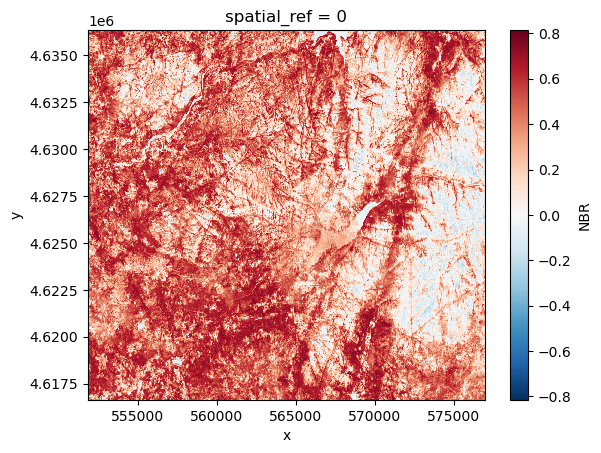

In [ ]:
prefire_burnratio.plot()

### Plotting After

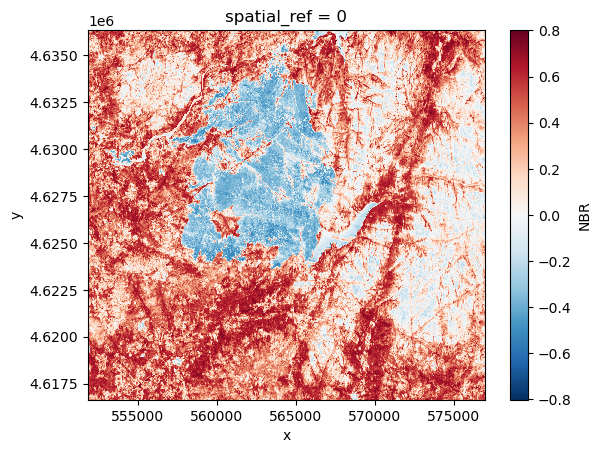

In [10]:
postfire_burnratio.plot()

### Plotting Delta

The plot below highligths the burnt regions.

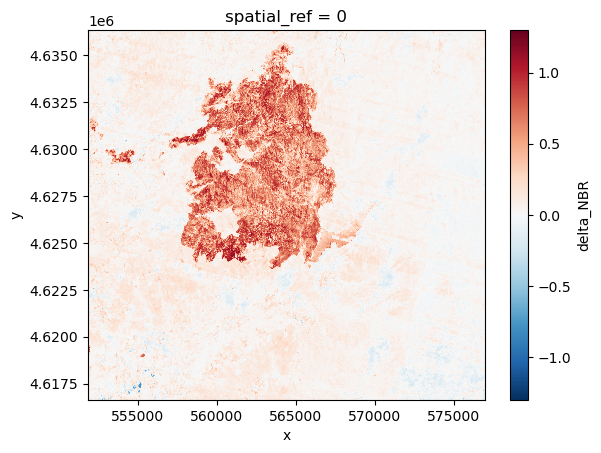

In [11]:
dnbr_dataset.delta_NBR.plot()

(areas_FIRE)=
## Analysing Burnt Areas 

Great, now that we've calculated the delta NBR (dNBR), we can estimate the amount of area that was burned. First we need to classify which pixels are actually burned and then calculate the area that was burned.

To classify burned area we can use the dNBR reference ratio ratios described in: [https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio](https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio) - and estimate the moderate to severe burnt areas. **i.e. the areas with a dNBR of above 0.440**

![img](https://un-spider.org/sites/default/files/table+legend.PNG)

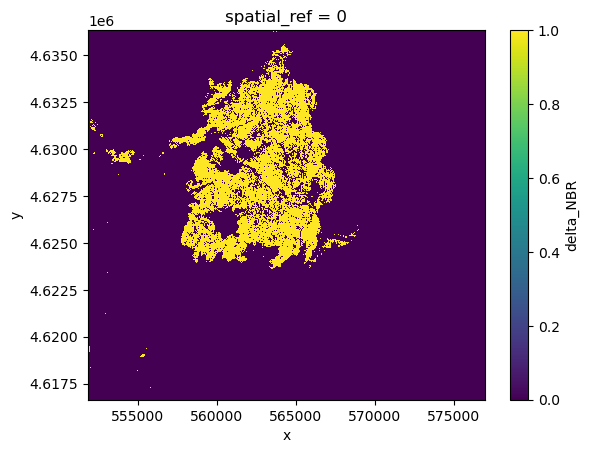

In [12]:
BURN_THRESH = 0.440
burn_mask = (
    dnbr_dataset.delta_NBR > BURN_THRESH
)  # True/False mask, same shape as raster
burn_mask.plot()

# save the burn_mask to our dataset
dnbr_dataset["burned_ha_mask"] = burn_mask

(burnt_area_FIRE)=
## Burnt Area

Now with the above a data mask where all pixels classified as burnt are 1 and the non burnt ones are 0. To calculate burnt area, we simply sum all pixels and multiply them by the area which a pixel covers (i.e. the resolution, which in our case is 10m/p).

At the same step we will convert our metric to hectares (ha).

In [13]:
# dx, dy = dnbr_dataset.delta_NBR.rio.resolution()
dx = 10.0
dy = -10.0
pixel_area_ha = abs(dx * dy) / 1e4  # 10m × 10m = 0.01 ha

pixels_burnt = burn_mask.sum().compute().item()  # integer number of burnt pixels
burnt_area_ha = pixels_burnt * pixel_area_ha

print(f"Burnt area   : {burnt_area_ha:,.2f} ha")

Burnt area   : 5,506.85 ha


In [14]:
cluster.close()

(links_FIRE)=
## Links and Refernces

* https://www.sciencedirect.com/science/article/pii/S1470160X22004708#f0035
* https://github.com/yobimania/dea-notebooks/blob/e0ca59f437395f7c9becca74badcf8c49da6ee90/Fire%20Analysis%20Compiled%20Scripts%20(Gadi)/dNBR_full.py
* https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio](https://un-spider.org/advisory-support/recommended-practices/recommended-practice-burn-severity/in-detail/normalized-burn-ratio
* https://github.com/bcdev/xrlint/tree/main/docs
* https://xcube.readthedocs.io/en/latest/
* https://docs.dask.org/en/stable/
* https://docs.xarray.dev/en/stable
* https://zarr.readthedocs.io/en/stable/
* https://corteva.github.io/rioxarray/stable/examples/reproject_match.html

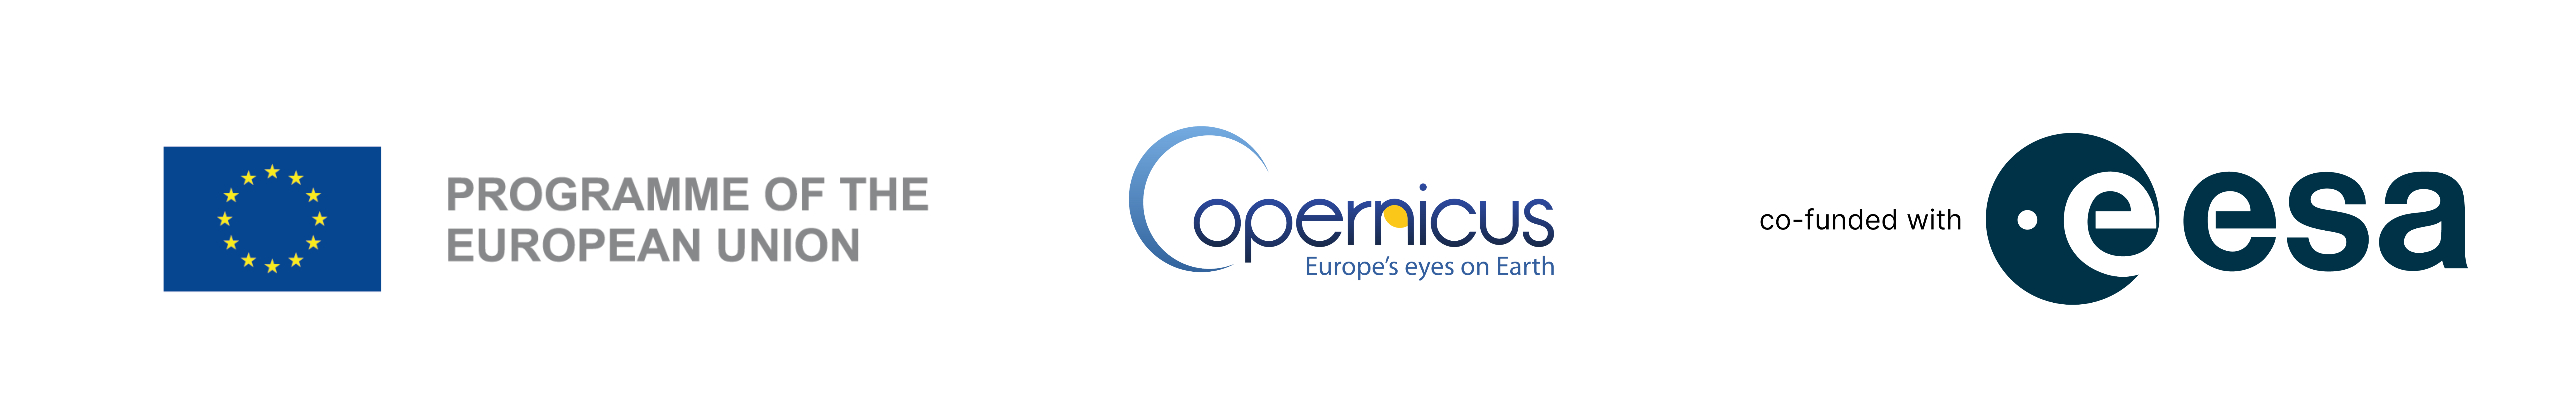